In [99]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from google.colab import drive

In [1]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Reading Data

In [100]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
folder_path='/content/drive/My Drive/Processed Data'
renewal_calls_file_path = folder_path+'/processed_renewal_calls_data.csv'
billings_file_path=folder_path+'/processed_data_of_billing.csv'
renewal_calls = pd.read_csv(renewal_calls_file_path)
billings = pd.read_csv(billings_file_path)

In [102]:
renewal_calls.head()

,co_ref,log_calls,log_days,mid_price_log,mid_price_log_flag,offering,price,process,recognition,service,...,agent_customer_communication,agent_customer_retention,agent_customer_service___support,agent_discount_and_offer,agent_not_mentioned,agent_other,agent_payment,agent_price_and_cost,total_past_contracts,churn
0,AA0584,1.098612,6.483107,NaN,1,0,0,0,0,1,...,False,False,False,False,True,False,False,False,4,0
1,AA0641,1.386294,6.131226,NaN,1,0,0,0,0,0,...,False,False,False,False,True,False,False,False,3,0
2,AA0784,1.386294,3.367296,NaN,1,0,0,0,0,0,...,True,False,False,False,False,False,False,False,1,0
3,AA0794,2.079442,4.795791,NaN,1,0,0,0,0,0,...,False,False,True,False,False,False,False,False,3,0
4,AA0882,0.693147,5.111988,NaN,1,0,0,0,0,0,...,False,False,False,False,True,False,False,False,1,0


In [103]:
billings.head()

,Co_Ref,Total_Renewal_Score_New,Tenure_Years,Band,call_count_window,Status_Scores,Payment_Timeframe,Sustainability_Score,Tenure_Scores,is_closed,Proforma_Membership_Status
0,34595,42.5,2.0,1,0,9,-297.0,8.0,8.0,1,4
1,5407,45.5,15.0,2,1,9,0.0,9.5,9.5,1,4
2,26728,44.0,11.0,13,0,9,0.0,8.0,9.5,1,4
3,11181,45.5,17.0,14,1,9,0.0,9.5,9.5,0,4
4,30241,44.0,10.0,14,0,8,0.0,9.0,9.5,0,4


# Scaling Numerical Columns

In [56]:
X = renewal_calls.drop('churn',axis=1).copy()
y = renewal_calls['churn'].copy()

In [57]:
continuous_cols = ['log_calls', 'log_days','total_past_contracts','mid_price_log', 'total_comp_mentions']
continuous_cols_tree_based = ['log_calls', 'log_days', 'mid_price_log', 'total_comp_mentions']

In [58]:
X_log= X.fillna({'mid_price_log':renewal_calls['mid_price_log'].median()})

In [59]:
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Feature matrix shape: (35839, 36)
Target distribution:
churn
0    28931
1     6908
Name: count, dtype: int64


# Spliting the dataset

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

In [61]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling the Numerical Values

#### Logistic Regression

In [62]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
y_train_scaled = y_train.copy()

X_test_scaled = X_test.copy()
X_test_scaled[continuous_cols] = scaler.fit_transform(X_test[continuous_cols])
y_test_scaled = y_test.copy()

#### Tree Based Models

In [63]:
X_train_tree_copy = X_train_tree.copy()
y_train_tree_copy = y_train_tree.copy()
X_test_tree_copy = X_test_tree.copy()
y_test_tree_copy = y_test_tree.copy()

# Class Imbalance

In [64]:
classes = np.unique(y_train_scaled)
weights = compute_class_weight('balanced', classes=classes, y=y_train_scaled)
print(dict(zip(classes, weights)))

{np.int64(0): np.float64(0.6193778353856124), np.int64(1): np.float64(2.5941910966340935)}


# **Model Training**

## Logistic Regression

In [65]:
print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train_scaled)


LOGISTIC REGRESSION RESULTS


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [66]:
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [67]:
print("\nClassification Report:")
print(classification_report(y_test_scaled, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      5786
           1       0.54      0.81      0.65      1382

    accuracy                           0.83      7168
   macro avg       0.74      0.82      0.77      7168
weighted avg       0.87      0.83      0.84      7168



In [68]:
print(f"AUC: {roc_auc_score(y_test_scaled, y_proba_lr):.4f}")
print("Confusion Matrix:")
confusion_matrix(y_test_scaled, y_pred_lr)

AUC: 0.8899
Confusion Matrix:


array([[4833,  953],
       [ 266, 1116]])

In [69]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('coefficient', ascending=False)

In [70]:
print("\nTop 15 coefficients (positive = increases churn):")
coef_df.head(15)


Top 15 coefficients (positive = increases churn):


,feature,coefficient,odds_ratio
17,renewal_decision_bin,1.737226,5.681559
25,agent_cancellation___termination___closure,1.103651,3.015156
18,desire_code,0.868392,2.383075
31,agent_not_mentioned,0.705795,2.025456
22,reaction_other,0.640881,1.898153
28,agent_customer_retention,0.610604,1.841544
0,log_calls,0.587637,1.799730
19,reaction_clarification___justification___inquiry,0.481758,1.618919
21,reaction_not_mentioned,0.444397,1.559549
1,log_days,0.428726,1.535300


In [71]:
print("\nBottom 15 coefficients (negative = decreases churn):")
coef_df.tail(15)


Bottom 15 coefficients (negative = decreases churn):


,feature,coefficient,odds_ratio
6,process,-0.030168,0.970282
29,agent_customer_service___support,-0.053981,0.947450
8,service,-0.056952,0.944639
5,price,-0.093313,0.910908
16,discount_or_waiver_requested_bin,-0.137942,0.871150
11,explicit_switching_intent_bin,-0.250911,0.778092
7,recognition,-0.263976,0.767992
24,agent_auto___automatic,-0.317204,0.728182
26,agent_confirmation___acceptance___agreement,-0.322236,0.724527
15,other_complaint_bin,-0.511690,0.599482


## Random Forest Regressor

In [72]:
print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_tree, y_train_tree)


RANDOM FOREST RESULTS


RandomForestClassifier(class_weight='balanced', random_state=42)

In [73]:
y_pred_rf = rf.predict(X_test_tree)
y_proba_rf = rf.predict_proba(X_test_tree)[:, 1]

In [74]:
print("\nClassification Report:")
print(classification_report(y_test_tree, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      5786
           1       0.66      0.64      0.65      1382

    accuracy                           0.87      7168
   macro avg       0.79      0.78      0.78      7168
weighted avg       0.87      0.87      0.87      7168



In [75]:
print(f"AUC: {roc_auc_score(y_test_tree, y_proba_rf):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_tree, y_pred_rf))

AUC: 0.8743
Confusion Matrix:
[[5332  454]
 [ 495  887]]


In [76]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [77]:
print("\nTop 15 feature importances (Random Forest):")
importance_df.head(15)


Top 15 feature importances (Random Forest):


,feature,importance
1,log_days,0.349974
35,total_past_contracts,0.200519
18,desire_code,0.116354
0,log_calls,0.106708
17,renewal_decision_bin,0.070089
25,agent_cancellation___termination___closure,0.025535
2,mid_price_log,0.018117
31,agent_not_mentioned,0.017063
33,agent_payment,0.010823
9,total_comp_mentions,0.010684


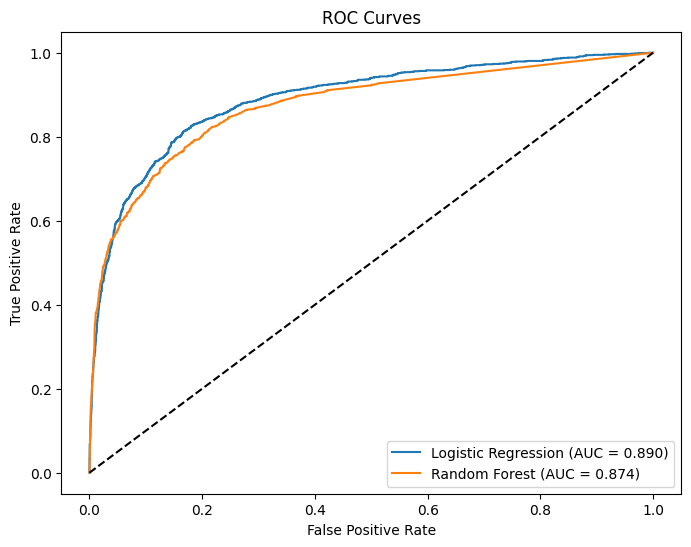

In [ ]:

plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test_scaled, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_tree, y_proba_rf)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test_scaled, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test_tree, y_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()